<a href="https://colab.research.google.com/github/gleo1973/tp-laboratorio-mcag-1c2026/blob/main/Laboratorio_TP_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Universidad de Buenos Aires · Facultad de Ciencias Económicas  
Tecnicatura Universitaria en Gestión y Análisis de Datos en Organizaciones*

# **Trabajo Práctico Grupal**
Exploración, análisis y presentación de datos reales asistida por IA  

## Análisis y comparación de los equipos de la Copa Mundial de Fútbol 2026.

*Por Leonardo Gomez, Fernando Morichetti y Carla Garibotti.*

---




In [33]:
#Importamos las librerías que vamos a utilizar

import pandas as pd #para manejo de archivos de datos
import numpy as np #para hacer operaciones matemáticas
import matplotlib.pyplot as plt #para hacer gráficos
import seaborn as sns #para hacer gráficos

In [34]:
#importamos la tabla con los paises que participan del torneo
#fuente: https://www.kaggle.com/datasets/harrachimustapha/fifa-world-cup-team-dataset

df_paises = pd.read_csv("datos/raw/paises.csv")

#importamos el listado de codigos de paises
#fuente: https://github.com/openpotato/fifa-codes/blob/main/src/fifa-member-associations.csv
df_cod_paises = pd.read_csv("datos/raw/fifa-member-associations.csv")


In [35]:
df_paises["team"].unique()

array(['France', 'Spain', 'Argentina', 'England', 'Portugal', 'Brazil',
       'Netherlands', 'Morocco', 'Belgium', 'Germany', 'Croatia',
       'Colombia', 'Senegal', 'Mexico', 'United States', 'Uruguay',
       'Japan', 'Switzerland', 'Iran', 'Turkey', 'Ecuador', 'Austria',
       'South Korea', 'Australia', 'Algeria', 'Egypt', 'Canada', 'Norway',
       'Panama', 'Ivory Coast', 'Sweden', 'Paraguay', 'Czech Republic',
       'Scotland', 'Tunisia', 'DR Congo', 'Uzbekistan', 'Qatar', 'Iraq',
       'South Africa', 'Saudi Arabia', 'Jordan', 'Bosnia and Herzegovina',
       'Cape Verde', 'Ghana', 'Cura?o', 'Haiti', 'New Zealand'],
      dtype=object)

In [36]:
# Se verifica que un valor quedó mal, permite identificar y aislar filas donde el nombre del equipo está corrupto para su correccion.
df_paises[df_paises['team'].str.contains(r'\?', na=False)]

,version,team,continent,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,world_cup_titles_before,...,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before,winner,finalist,semi_finalist,quarter_finalist
45,2026,Cura?o,North America,0,55,39,12,10,10,0,...,0,0,0,0,0,0,NaN,NaN,NaN,NaN


In [37]:
# Corregimos ese valor puntual
df_paises['team'] = df_paises['team'].replace('Cura?o', 'Curaçao')
df_paises[df_paises['team'].str.contains(r'\?', na=False)]

,version,team,continent,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,world_cup_titles_before,...,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before,winner,finalist,semi_finalist,quarter_finalist


In [38]:
df_cod_paises.columns

Index(['Country.Iso3166.Alpha2Code', 'Country.Name',
       'Subdivision.Iso3166.Code', 'FIFA.Code', 'FIFA.MemberAssociation',
       'FIFA.Joined', 'Established', 'ContinentalConfederation.Code',
       'ContinentalConfederation.Name'],
      dtype='object')

In [39]:
# Merge para traer el código FIFA
df_paises_merge = df_paises.merge(
    df_cod_paises,
    left_on='team',
    right_on='Country.Name',
    how='left'
)


In [41]:
df_paises_merge.head()

,version,team,continent,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,world_cup_titles_before,...,quarter_finalist,Country.Iso3166.Alpha2Code,Country.Name,Subdivision.Iso3166.Code,FIFA.Code,FIFA.MemberAssociation,FIFA.Joined,Established,ContinentalConfederation.Code,ContinentalConfederation.Name
0,2026,France,Europe,0,85,32,25,6,7,2,...,NaN,FR,France,NaN,FRA,Fédération Française de Football (FFF),1904.0,1919.0,UEFA,Union of European Football Associations (UEFA)
1,2026,Spain,Europe,0,104,32,29,2,8,1,...,NaN,ES,Spain,NaN,ESP,Real Federación Española de Fútbol (FEF),1904.0,1913.0,UEFA,Union of European Football Associations (UEFA)
2,2026,Argentina,South America,0,80,14,30,4,3,3,...,NaN,AR,Argentina,NaN,ARG,Asociación del Fútbol Argentino (AFA),1912.0,1893.0,CONMEBOL,Confederação Sul-Americana de Futebol (CONMEBOL)
3,2026,England,Europe,0,82,23,26,6,7,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026,Portugal,Europe,0,98,31,26,5,7,0,...,NaN,PT,Portugal,NaN,POR,Federação Portuguesa de Futebol (FPF),1923.0,1914.0,UEFA,Union of European Football Associations (UEFA)


In [42]:
# Verificar que no quedaron equipos sin código (Son los equipos que no estan en la Copa 2026)
sin_codigo = df_paises_merge[df_paises_merge['FIFA.Code'].isna()][['team']]
print("Sin código FIFA:", sin_codigo)

Sin código FIFA:               team
3          England
6      Netherlands
14   United States
18            Iran
19          Turkey
22     South Korea
29     Ivory Coast
32  Czech Republic
33        Scotland
35        DR Congo
43      Cape Verde


In [ ]:
# Busco la lista de paises en esta tabla para poder corregirlos con un diccionario
df_cod_paises["Country.Name"].unique()

array(['Andorra', 'United Arab Emirates (the)', 'Afghanistan',
       'Antigua and Barbuda', 'Anguilla', 'Albania', 'Armenia', 'Angola',
       'Argentina', 'American Samoa', 'Austria', 'Australia', 'Aruba',
       'Azerbaijan', 'Bosnia and Herzegovina', 'Barbados', 'Bangladesh',
       'Belgium', 'Burkina Faso', 'Bulgaria', 'Bahrain', 'Burundi',
       'Benin', 'Bermuda', 'Brunei Darussalam',
       'Bolivia (Plurinational State of)', 'Brazil', 'Bahamas (the)',
       'Bhutan', 'Botswana', 'Belarus', 'Belize', 'Canada',
       'Congo (the Democratic Republic of the)',
       'Central African Republic (the)', 'Congo (the)', 'Switzerland',
       "Côte d'Ivoire", 'Cook Islands (the)', 'Chile', 'Cameroon',
       'China', 'Colombia', 'Costa Rica', 'Cuba', 'Cabo Verde', 'Curaçao',
       'Cyprus', 'Czechia', 'Germany', 'Djibouti', 'Denmark', 'Dominica',
       'Dominican Republic (the)', 'Algeria', 'Ecuador', 'Estonia',
       'Egypt', 'Eritrea', 'Spain', 'Ethiopia', 'Finland', 'Fiji',
  

In [45]:
# Copio los países que no se cruzaron y genero el diccionario para renombrarlos en la tabla de códigos.
country_name_dict = {
    "Iran (Islamic Republic of)" : "Iran",
    "Netherlands (Kingdom of the)" : "Netherlands",
    "United States of America (the)" : "United States",
    "Türkiye" : "Turkey",
    'Korea (the Republic of)' : "South Korea",
    "Côte d'Ivoire" : "Ivory Coast",
    'Czechia' : "Czech Republic",
    'Congo (the)' : "DR Congo",
    'Cabo Verde' : "Cape Verde"
}
df_cod_paises.replace({"Country.Name": country_name_dict},inplace=True)

In [ ]:
# Reviso que haya cambiado los valores
df_cod_paises["Country.Name"].unique()

array(['Andorra', 'United Arab Emirates (the)', 'Afghanistan',
       'Antigua and Barbuda', 'Anguilla', 'Albania', 'Armenia', 'Angola',
       'Argentina', 'American Samoa', 'Austria', 'Australia', 'Aruba',
       'Azerbaijan', 'Bosnia and Herzegovina', 'Barbados', 'Bangladesh',
       'Belgium', 'Burkina Faso', 'Bulgaria', 'Bahrain', 'Burundi',
       'Benin', 'Bermuda', 'Brunei Darussalam',
       'Bolivia (Plurinational State of)', 'Brazil', 'Bahamas (the)',
       'Bhutan', 'Botswana', 'Belarus', 'Belize', 'Canada',
       'Congo (the Democratic Republic of the)',
       'Central African Republic (the)', 'DR Congo', 'Switzerland',
       'Ivory Coast', 'Cook Islands (the)', 'Chile', 'Cameroon', 'China',
       'Colombia', 'Costa Rica', 'Cuba', 'Cape Verde', 'Curaçao',
       'Cyprus', 'Czech Republic', 'Germany', 'Djibouti', 'Denmark',
       'Dominica', 'Dominican Republic (the)', 'Algeria', 'Ecuador',
       'Estonia', 'Egypt', 'Eritrea', 'Spain', 'Ethiopia', 'Finland',
       '

In [47]:
# Merge para traer el código FIFA
df_paises_merge2 = df_paises.merge(
    df_cod_paises,
    left_on='team',
    right_on='Country.Name',
    how='left'
)

In [130]:
df_paises_merge2.columns

Index(['version', 'team', 'continent', 'is_host', 'goals_scored_last_4y',
       'goals_received_last_4y', 'wins_last_4y', 'losses_last_4y',
       'draws_last_4y', 'world_cup_titles_before',
       'squad_total_market_value_eur', 'fifa_rank_pre_tournament',
       'fifa_points_pre_tournament', 'squad_avg_age',
       'world_cup_participations_before', 'groups_passed_before',
       'round16_before', 'quarterfinals_before', 'semifinals_before',
       'finals_before', 'winner', 'finalist', 'semi_finalist',
       'quarter_finalist', 'Country.Iso3166.Alpha2Code', 'Country.Name',
       'Subdivision.Iso3166.Code', 'FIFA.Code', 'FIFA.MemberAssociation',
       'FIFA.Joined', 'Established', 'ContinentalConfederation.Code',
       'ContinentalConfederation.Name'],
      dtype='object')

In [ ]:
# Verificar que no quedaron equipos sin código
sin_codigo = df_paises_merge2[df_paises_merge2['FIFA.Code'].isna()][['team']]
print("Sin código FIFA:", sin_codigo)

Sin código FIFA:         team
3    England
33  Scotland


In [ ]:
# Completamos los códigos de los equipos que no se cruzaron porque son del Reino Unido, que compiten por separado pero tienen el mismo código ISO3166-2
# A los fines del análisis, vamos a asignarles el mismo código ISO3166-2, pero cada uno tendrá su propio código FIFA.

df_paises_merge2.loc[df_paises_merge2["team"] == "England", "FIFA.Code"] = "ENG"
df_paises_merge2.loc[df_paises_merge2["team"] == "England", "Country.Iso3166.Alpha2Code"] = "GB"
df_paises_merge2.loc[df_paises_merge2["team"] == "Scotland", "FIFA.Code"] = "SCO"
df_paises_merge2.loc[df_paises_merge2["team"] == "Scotland", "Country.Iso3166.Alpha2Code"] = "GB"

In [ ]:
# Verificar que no quedaron equipos sin código
sin_codigo = df_paises_merge2[df_paises_merge2['FIFA.Code'].isna()][['team']]
print("Sin código FIFA:", sin_codigo)

Sin código FIFA: Empty DataFrame
Columns: [team]
Index: []


In [ ]:
# Sumo datos estadísticos con otra base de datos
# Fuente: https://simplemaps.com/data/countries


df_info_paises = pd.read_csv("datos/raw/country_info.csv")

In [140]:
# Merge para traer la información estadística
# Observación: Tanto Escocia como Inglaterra tendrán ambos la información de Reino Unido en las columnas que agregaremos más adelante. 
# Tendremos que eliminar duplicados cuando sumemos la información por continente.

df_paises_merge3 = df_paises_merge2.merge(
    df_info_paises,
    left_on='Country.Iso3166.Alpha2Code',
    right_on='iso2',
    how='left'
)

In [62]:
# Verificar que no quedaron equipos sin código
sin_codigo = df_paises_merge3[df_paises_merge3['iso2'].isna()][['team']]
print("Sin código ISO:", sin_codigo)

Sin código ISO: Empty DataFrame
Columns: [team]
Index: []


In [64]:
df_paises_merge3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 51 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   version                          48 non-null     int64  
 1   team                             48 non-null     object 
 2   continent_x                      48 non-null     object 
 3   is_host                          48 non-null     int64  
 4   goals_scored_last_4y             48 non-null     int64  
 5   goals_received_last_4y           48 non-null     int64  
 6   wins_last_4y                     48 non-null     int64  
 7   losses_last_4y                   48 non-null     int64  
 8   draws_last_4y                    48 non-null     int64  
 9   world_cup_titles_before          48 non-null     int64  
 10  squad_total_market_value_eur     48 non-null     int64  
 11  fifa_rank_pre_tournament         48 non-null     int64  
 12  fifa_points_pre_tourname

In [73]:
#filtramos para conservar las columnas que nos interesan
df_paises_f = df_paises_merge3[["fifa_rank_pre_tournament", "team", "continent_x", "squad_total_market_value_eur", "fifa_points_pre_tournament", "Country.Iso3166.Alpha2Code", "FIFA.Code", "population", "area", "gdp", "language", "religion"]].copy()


In [74]:
#armamos un diccionario para renombrar las columnas
columnas = {"fifa_rank_pre_tournament":"ranking_FIFA",
            "team":"pais",
            "continent_x":"continente",
            "squad_total_market_value_eur":"valor_en_euros",
            "fifa_points_pre_tournament":"puntos_FIFA",
            "Country.Iso3166.Alpha2Code" : "codigo_ISO",
            "FIFA.Code" : "codigo_FIFA",
            "population" : "poblacion",
            "gdp" : "pbi",
            "language" : "idioma"
            }
df_paises_f.rename(columns=columnas,inplace=True)

In [95]:
df_paises_f["pbi_per_capita"] = df_paises_f["pbi"] / df_paises_f["poblacion"]

In [96]:
df_paises_f.dtypes

ranking_FIFA        int64
pais               object
continente         object
valor_en_euros      int64
puntos_FIFA       float64
codigo_ISO         object
codigo_FIFA        object
poblacion         float64
area              float64
pbi               float64
idioma             object
religion           object
pbi_per_capita    float64
dtype: object

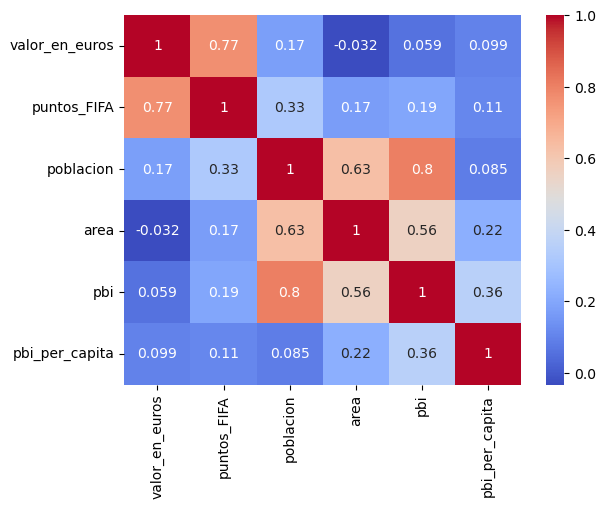

In [139]:
# Creamos un mapa de calor para visualizar la correlación entre las variables
# Selecionamos solo las columnas con variables numéricas de interés (ignoramos el ranking, los códigos)

numeric_df = df_paises_f[["valor_en_euros", "puntos_FIFA", "poblacion", "area", "pbi", "pbi_per_capita"]]

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()


Conclusión: Hay una correlación fuerte entre los puntos y el valor estimado del equipo, lo cual es lógico. Estos valores, sin embargo, no tienen ninguna correlación con los estadísticos del país: población, area y PBI.


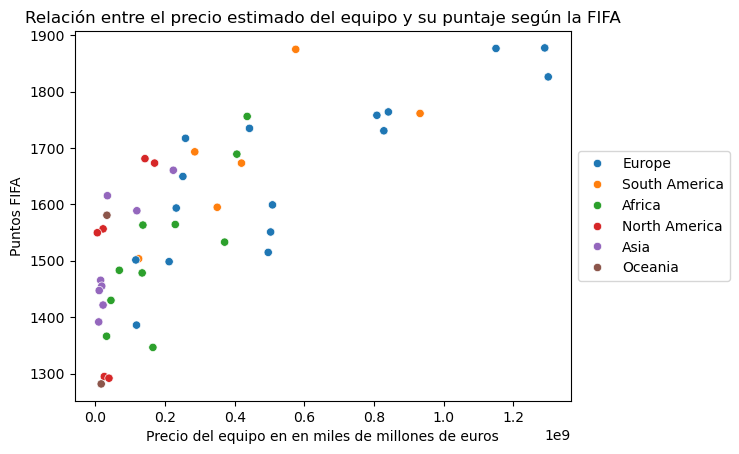

In [105]:
sns.scatterplot(
    data=df_paises_f, 
    x='valor_en_euros', 
    y="puntos_FIFA",
    hue='continente', #el color lo da el continente
    legend="full" #pone la leyenda
)
plt.title("Relación entre el precio estimado del equipo y su puntaje según la FIFA")
plt.xlabel('Precio del equipo en en miles de millones de euros')
plt.ylabel("Puntos FIFA")
plt.legend(bbox_to_anchor=(1, 0.5), loc='center left')

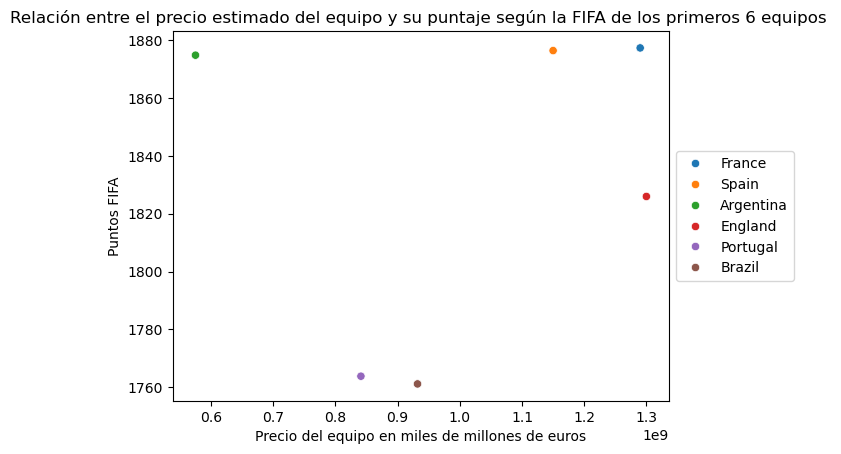

In [104]:
sns.scatterplot(
    data=df_paises_f.head(6), #detalle de los primeros 6 paises
    x='valor_en_euros', 
    y="puntos_FIFA",
    hue="pais", #el color lo da el pais
    legend="full" #pone la leyenda
)
plt.title("Relación entre el precio estimado del equipo y su puntaje según la FIFA de los primeros 6 equipos ")
plt.xlabel('Precio del equipo en miles de millones de euros')
plt.ylabel("Puntos FIFA")
plt.legend(bbox_to_anchor=(1, 0.5), loc='center left')

Conclusión: Se ve en el scatterplot la relación entre el valor del equipo y su puntaje. Una excepción a la tendencia es Argentina, estando el equipo a un precio mucho menor que lo que su puntaje indicaría.

<Axes: title={'center': 'puntos_FIFA'}, xlabel='continente'>

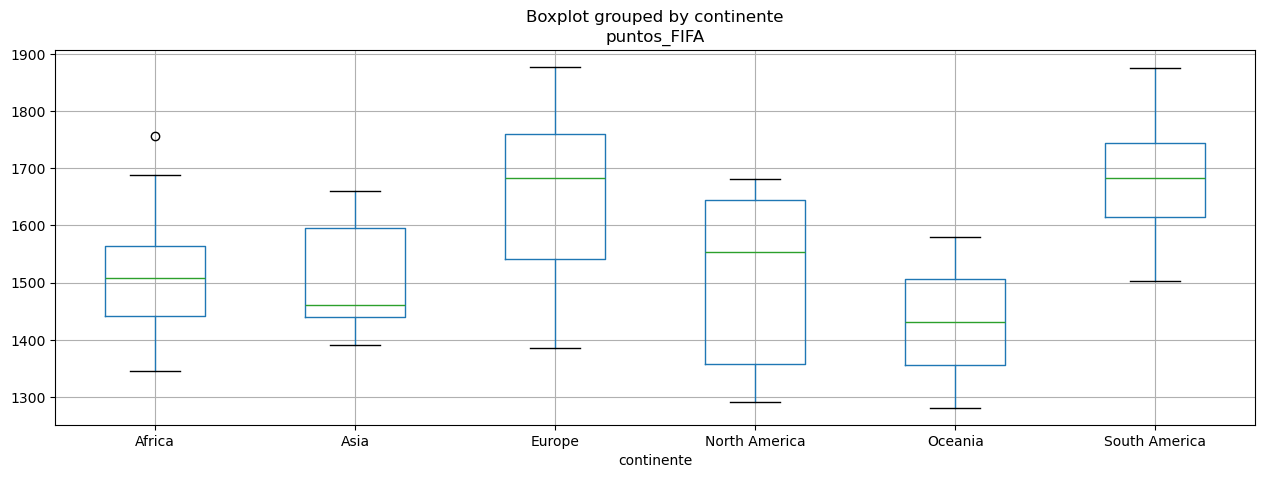

In [ ]:
# Hacemos un boxplot para ver la distribución de los puntos FIFA por continente
#FALTA ELIMINAR EL DUPLICADO DE REINO UNIDO PARA QUE NO SE REPITA EN EL GRÁFICO

df_paises_f.boxplot('puntos_FIFA', 'continente', figsize=(15, 5), grid=True)

Conclusión: El continente de origen del país sí parece ser un indicador importante del puntaje del equipo. América del Sur y Europa tienen puntajes superiores. Posibles explicaciones: la competencia intra continental obliga a subir el nivel.

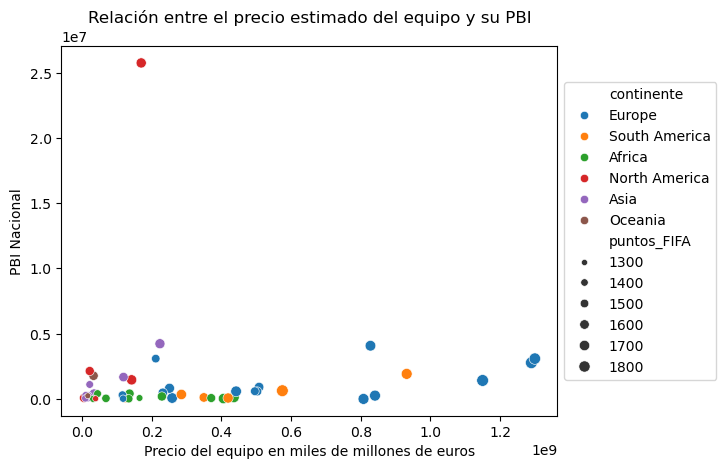

In [103]:

sns.scatterplot(
    data=df_paises_f, 
    x='valor_en_euros', 
    y="pbi",
    size="puntos_FIFA", #el tamaño lo da el puntaje
    hue="continente",
    legend="brief" #pone la leyenda
)
plt.title("Relación entre el precio estimado del equipo y su PBI")
plt.xlabel('Precio del equipo en miles de millones de euros')
plt.ylabel("PBI Nacional")
plt.legend(bbox_to_anchor=(1, 0.5), loc='center left')
plt.show()

Conclusión: Estados Unidos tiene un PBI mucho mayor que el resto de los países y distorsiona el análisis. Vamos mejor a mirar PBI per cápita:

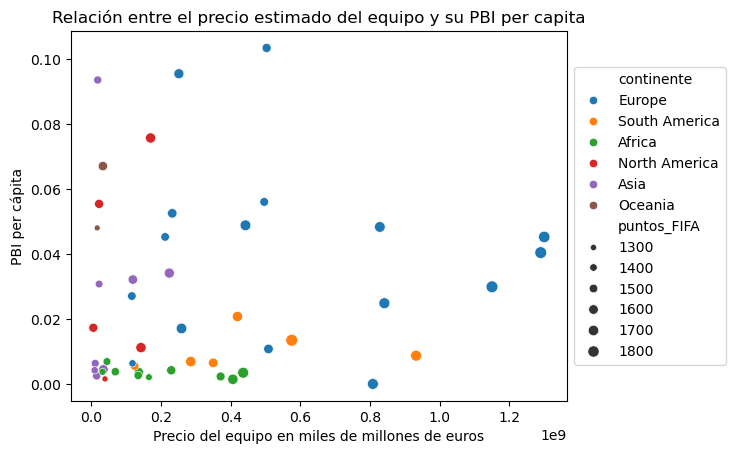

In [ ]:
sns.scatterplot(
    data=df_paises_f, 
    x='valor_en_euros', 
    y="pbi_per_capita",
    size="puntos_FIFA", #el tamaño lo da el puntaje
    hue="continente",
    legend="brief" #pone la leyenda
)
plt.title("Relación entre el precio estimado del equipo y su PBI per capita")
plt.xlabel('Precio del equipo en miles de millones de euros')
plt.ylabel("PBI per cápita")
plt.legend(bbox_to_anchor=(1, 0.5), loc='center left')
plt.show()

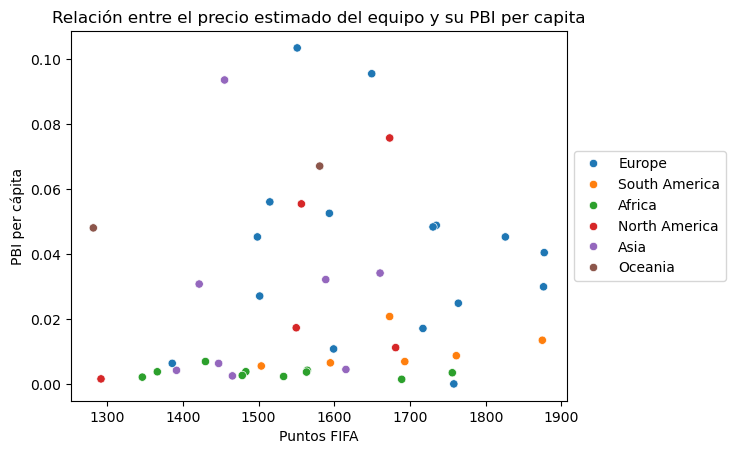

In [107]:
sns.scatterplot(
    data=df_paises_f, 
    x='puntos_FIFA', 
    y="pbi_per_capita",
    hue="continente",
    legend="brief" #pone la leyenda
)
plt.title("Relación entre el precio estimado del equipo y su PBI per capita")
plt.xlabel('Puntos FIFA')
plt.ylabel("PBI per cápita")
plt.legend(bbox_to_anchor=(1, 0.5), loc='center left')
plt.show()

<Axes: title={'center': 'puntos_FIFA'}, xlabel='religion'>

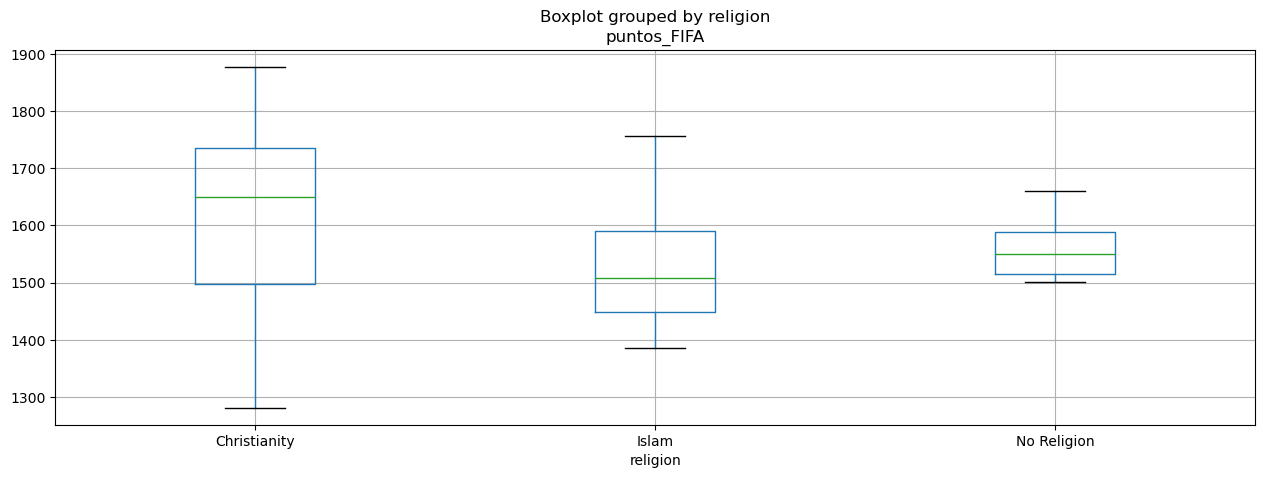

In [108]:
df_paises_f.boxplot('puntos_FIFA', 'religion', figsize=(15, 5), grid=True)

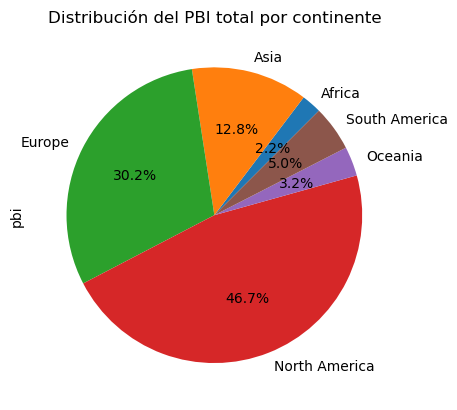

In [121]:
#Hacemos un gráfico de torta del PBI total por continente

df_paises_f["pbi"].groupby(df_paises_f["continente"]).sum().plot.pie(startangle=45,autopct="%.1f%%")
#plt.legend(bbox_to_anchor=(1.2, 0.5), loc='center left')
plt.title("Distribución del PBI total por continente")
plt.show()

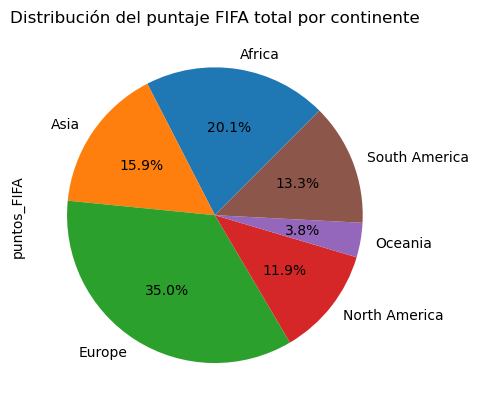

In [122]:
#Hacemos un gráfico de torta del puntaje FIFA total por continente

df_paises_f["puntos_FIFA"].groupby(df_paises_f["continente"]).sum().plot.pie(startangle=45,autopct="%.1f%%")
#plt.legend(bbox_to_anchor=(1.2, 0.5), loc='center left')
plt.title("Distribución del puntaje FIFA total por continente")
plt.show()

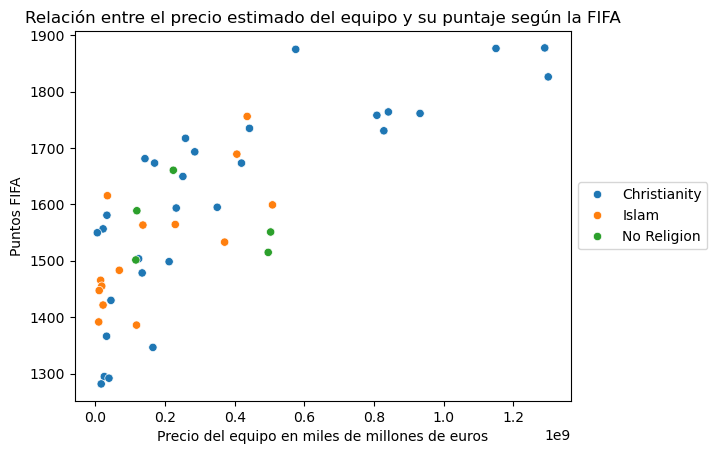

In [128]:
sns.scatterplot(
    data=df_paises_f, 
    x='valor_en_euros', 
    y="puntos_FIFA",
    hue='religion', #el color lo da la religion
    legend="full" #pone la leyenda
)
plt.title("Relación entre el precio estimado del equipo y su puntaje según la FIFA")
plt.xlabel('Precio del equipo en miles de millones de euros')
plt.ylabel("Puntos FIFA")
plt.legend(bbox_to_anchor=(1, 0.5), loc='center left')